# Circular mesh optimization

A **circular mesh** is a quad mesh whose faces are planar and inscribed in circles. Such
meshes are used in architectural geometry: they admit offset meshes at constant face
distance and have a torsion-free support structure.

This notebook takes a quad mesh that is neither planar nor circular and optimizes it with
**hanan**, then shows every stage in the **kayviz** browser viewer:

1. load a quad mesh and perturb it;
2. measure how far each face is from planar and from circular;
3. set up the optimizer (planarity + circularity + fairness);
4. run it and look at the result, with the circumcircle of every face.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import kayviz as kv
from hanan import glyphs
from hanan.geometry.io import read_obj
from hanan.geometry.construction import normalize_vertices
from hanan.geometry.mesh import Mesh
from hanan.optimization import Optimizer, Planarity, Cyclicity

kv.init()          # starts the viewer and prints its URL; open it in a browser
kv.show()          # in Jupyter this returns immediately

[kayviz] Viewer running at http://127.0.0.1:8001
[kayviz] Opening http://127.0.0.1:8001/?app=script


## 1. Input mesh

`data/pq_mesh.obj` is already a planar quad mesh, so we add noise to every vertex: the
input is then neither planar nor circular.

In [2]:
V0, F = read_obj("data/pq_mesh.obj")
V0 = normalize_vertices(V0)
F = np.asarray(F)

mesh = Mesh()
mesh.make_mesh(V0, F)
ei, ej = mesh.edge_vertices()
h = np.linalg.norm(V0[ei] - V0[ej], axis=1).mean()          # mean edge length

rng = np.random.default_rng(3)
V = V0 + 0.15 * h * rng.standard_normal(V0.shape)             # noise: 15% of an edge
mesh = Mesh()
mesh.make_mesh(V, F)
print(f"{len(V)} vertices, {len(F)} quads, mean edge length {h:.3f}")

Mesh |V|=90, |F|=72, |E|=161
Mesh |V|=90, |F|=72, |E|=161
90 vertices, 72 quads, mean edge length 0.116


## 2. How far from planar and circular?

- **Planarity error** of a quad: distance between its two diagonals, divided by the mean
  edge length (0 for a planar quad).
- **Circularity error**: for the circle through the face vertices (hanan's
  `compute_circumcircles_quad_mesh`), the spread of the vertex distances to the circle
  center, relative to the radius (0 when the four vertices lie on one circle).

In [3]:
from hanan.geometry.measures import compute_circumcircles_quad_mesh

def planarity_error(V):
    p0, p1, p2, p3 = (V[F[:, k]] for k in range(4))
    n = np.cross(p2 - p0, p3 - p1)
    n /= np.linalg.norm(n, axis=1, keepdims=True)
    return np.abs(np.einsum("ij,ij->i", p1 - p0, n)) / h

def circularity_error(V):
    C, _, R = compute_circumcircles_quad_mesh(V, F)
    d = np.linalg.norm(V[F] - C[:, None, :], axis=2)
    return (d.max(axis=1) - d.min(axis=1)) / R

def show(name, V, color):
    kv.register_surface_mesh(name, V, F, color=color, show_edges=True)
    kv.add_scalar_quantity(name, "planarity error", planarity_error(V), defined_on="faces")
    kv.add_scalar_quantity(name, "circularity error", circularity_error(V), defined_on="faces")

show("Input", V, color=(0.75, 0.75, 0.75))
print(f"input: max planarity error {planarity_error(V).max():.2e}, "
      f"max circularity error {circularity_error(V).max():.2e}")

input: max planarity error 4.87e-01, max circularity error 6.82e-01


## 3. The optimization problem

Variables (flattened into one vector by the optimizer):

| name | meaning |
|---|---|
| `v` | vertex positions |
| `n_f` | one unit normal per face (auxiliary) |
| `cf` | one circle center per face (auxiliary) |

Energy terms:

- **`Planarity`**: every face edge is orthogonal to its face normal `n_f`.
- **`Cyclicity`**: every circle center `cf` lies in its face plane and on the
  perpendicular bisector of every face edge, so the face vertices are equidistant from
  `cf`, i.e. concyclic.
- **fairness** of the vertices (`set_fairness`): a small, damped smoothness term that
  keeps faces from collapsing while the others converge.
- `unitize_variable("n_f")` keeps the normals of unit length.

The optimizer is a Levenberg–Marquardt method on these least-squares residuals.

In [4]:
opt = Optimizer()
opt.add_variable("v",   V.flatten())
opt.add_variable("n_f", mesh.face_normals.flatten())
opt.add_variable("cf",  mesh.face_barycenters().flatten())

planarity = Planarity()
planarity.name = "planarity"
opt.add_objective_term(planarity, args=([F]), w=1.0, ce=True)

cyclicity = Cyclicity()
cyclicity.name = "cyclicity"
opt.add_objective_term(cyclicity, args=(F, "v", "cf", "n_f"), w=1.0, ce=True)

opt.set_fairness("v", mesh.vertex_adjacency_list(), dim=3,
                 damp_factor=0.8, damp_iteration=10, w=0.01, ce=True)
opt.unitize_variable("n_f", 3, w=5)

opt.initialize_optimizer(verbose=False)
print("terms:", list(opt.get_term_weights_dict()))

Adding quadratic fairness for 56 vertices with 4 neighbors
Adding Laplacian fairness for 34 
terms: ['planarity', 'cyclicity', 'QuadFairness_v', 'Lap_Fairness_v', 'n_f_unit']


## 4. Optimize

Each step solves one linearized least-squares problem. The mesh in the viewer is updated
every 10 steps.

energy 2.75e-02 -> 1.34e-30
optimized: max planarity error 1.79e-16, max circularity error 2.40e-15
largest vertex displacement: 1.69 mean edge lengths


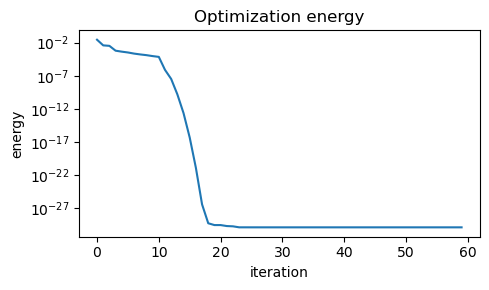

In [5]:
for it in range(60):
    opt.get_gradients()
    opt.optimize_step()
    if (it + 1) % 10 == 0:
        kv.register_surface_mesh("Optimized", opt.unpack("v").reshape(-1, 3), F,
                                 color=(0.35, 0.55, 0.85), show_edges=True)

V_opt = opt.unpack("v").reshape(-1, 3)
print(f"energy {opt.energy[0]:.2e} -> {opt.energy[-1]:.2e}")
print(f"optimized: max planarity error {planarity_error(V_opt).max():.2e}, "
      f"max circularity error {circularity_error(V_opt).max():.2e}")
print(f"largest vertex displacement: {np.linalg.norm(V_opt - V, axis=1).max() / h:.2f} mean edge lengths")

plt.figure(figsize=(5, 3))
plt.semilogy(opt.energy)
plt.xlabel("iteration"); plt.ylabel("energy"); plt.title("Optimization energy")
plt.tight_layout(); plt.show()

## 5. Result

The optimized mesh, coloured by its (now vanishing) errors, with the circle of every face
drawn from the optimized centers `cf`, normals `n_f` and the resulting radii. `hanan.glyphs`
turns the circles into a curve network; kayviz draws it.

In [6]:
C = opt.unpack("cf").reshape(-1, 3)
N = opt.unpack("n_f").reshape(-1, 3)
R = np.linalg.norm(V_opt[F[:, 0]] - C, axis=1)

show("Optimized", V_opt, color=(0.35, 0.55, 0.85))
kv.register_curve_network("Circumcircles", *glyphs.circles(C, N, R), color=(0.85, 0.2, 0.2))
kv.register_point_cloud("Circle centers", C, color=(0.85, 0.2, 0.2), radius=0.004)
kv.set_enabled("Input", False)
print("In the viewer: toggle 'Input' to compare, pick a scalar on 'Optimized' to see the errors.")

In the viewer: toggle 'Input' to compare, pick a scalar on 'Optimized' to see the errors.


## Going further

- Raise the `Cyclicity` weight, or lower the fairness weight, to trade smoothness for
  exactness.
- To keep the result close to a reference surface, add
  `opt.proximity_reference("v", V_ref, F_ref_triangles, w_proximity, w_gliding)`. Keep it
  weak: it competes with circularity when the reference itself is not circular.
- [`examples/polyhedral_mesh`](.) runs the same kind of optimization as an interactive
  app (`python run.py`), with sliders for the weights and live updates.